In [ ]:
pip install micrograd


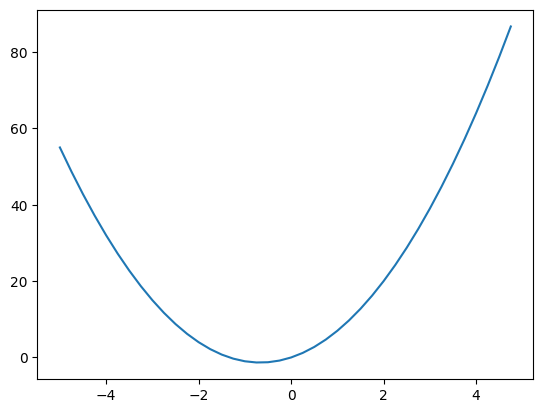

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
def f(x):
  return 3*x**2 +4*x
xs=np.arange(-5,5,0.25)
ys=f(xs)
plt.plot(xs,ys)
plt.show()


In [ ]:
h=0.0001
a=2.0
b=-3.0
c=10.0
d1=a*b+c
a+=h
d2=a*b+c
s=(d2-d1)/h
print(s)

-3.000000000010772


In [ ]:
class Value:
  def __init__(self,data,child=(),op=""):
    self.data=data
    self.backward=lambda:None
    self.prev=set(child)
    self.op=op
  def __repr__(self):
    return f"Value(data={self.data})"
  def __add__(self,other):
    other=other if isinstance(other,Value) else Value(other)
    out=Value(self.data+other.data,(self,other),'+')
    def backward():
      self.grad+=out.grad
      other.grad+=out.grad
    out.backward=backward

    return out
  def __mul__(self,other):
    out=Value(self.data*other.data)
    def backward():
      self.grad+=out.grad*other.data
      other.grad+=out.grad*self.data
    out.backward=backward
    return out
  def __rmul__(self,other):
      return self*other
  def __truediv__(self,other):
      return self*other**-1
  def __pow__(self,other):
    other=other if isinstance(other,Value) else Value(other)
    out=Value(self.data**other.data,(self,),f'**{other.data}')
    def backward():
      self.grad+=(other.data*(self.data**(other.data-1)))*out.grad
    out.backward=backward
    return out
    def tanh(self):
      x=self.data
      t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
      out=Value(t,(self,),'tanh')
      def backward():
        self.grad+=(1-t**2)*out.grad
      out.backward=backward
      return out
a=Value(2)
b=Value(3)

c=a+b
print(c.op)
a+1

+


Value(data=3)

In [ ]:
x1=3.0
w1=2.0
x2=5.0
w2=1.0
b=8.0
L=x1*w1+x2*w2+b


In [ ]:
import torch
x1=torch.Tensor([0.2]).double();x1.requires_grad=True
x2=torch.Tensor([0.3]).double();x2.requires_grad=True
w2=torch.Tensor([0.4]).double();w2.requires_grad=True
w1=torch.Tensor([0.5]).double();w1.requires_grad=True
b=torch.Tensor([0.1]).double();b.requires_grad=True
n=x1*w1+x2*w2+b
o=torch.tanh(n)
o.backward()
b.grad.item()

0.9042054603836086

In [ ]:
class Neuron:
  def __init__(self,nin):
    self.w=(Value(torch.randint(-1,1)) for _ in range(nin))
    self.b=Value(torch.randint(-1,1))
  def __call__(self):
    act=sum(wi*xi for wi,xi in zip(self.w,self.x))
    return act.tanh()


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving names.txt to names.txt


In [ ]:
words=open('names.txt','r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [ ]:
b={}
for w in words:
  chs=['<S>']+list(w)+['<E>']
  for ch1,ch2 in zip(chs,chs[1:]):
    bigram=(ch1,ch2)
    b[bigram]=b.get(bigram,0)+1



In [ ]:
sorted(b.items(),key=lambda kv:kv[-1])

[(('q', 'r'), 1),
 (('d', 'z'), 1),
 (('p', 'j'), 1),
 (('q', 'l'), 1),
 (('p', 'f'), 1),
 (('q', 'e'), 1),
 (('b', 'c'), 1),
 (('c', 'd'), 1),
 (('m', 'f'), 1),
 (('p', 'n'), 1),
 (('w', 'b'), 1),
 (('p', 'c'), 1),
 (('h', 'p'), 1),
 (('f', 'h'), 1),
 (('b', 'j'), 1),
 (('f', 'g'), 1),
 (('z', 'g'), 1),
 (('c', 'p'), 1),
 (('p', 'k'), 1),
 (('p', 'm'), 1),
 (('x', 'n'), 1),
 (('s', 'q'), 1),
 (('k', 'f'), 1),
 (('m', 'k'), 1),
 (('x', 'h'), 1),
 (('g', 'f'), 1),
 (('v', 'b'), 1),
 (('j', 'p'), 1),
 (('g', 'z'), 1),
 (('v', 'd'), 1),
 (('d', 'b'), 1),
 (('v', 'h'), 1),
 (('h', 'h'), 1),
 (('g', 'v'), 1),
 (('d', 'q'), 1),
 (('x', 'b'), 1),
 (('w', 'z'), 1),
 (('h', 'q'), 1),
 (('j', 'b'), 1),
 (('x', 'm'), 1),
 (('w', 'g'), 1),
 (('t', 'b'), 1),
 (('z', 'x'), 1),
 (('p', 'b'), 2),
 (('t', 'g'), 2),
 (('q', 's'), 2),
 (('t', 'x'), 2),
 (('f', 'k'), 2),
 (('b', 't'), 2),
 (('j', 'n'), 2),
 (('k', 'c'), 2),
 (('z', 'k'), 2),
 (('s', 'j'), 2),
 (('s', 'f'), 2),
 (('z', 'j'), 2),
 (('n', 'q

In [ ]:
import torch
N=torch.zeros((27,27),dtype=torch.int32)


In [ ]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}

In [ ]:

for w in words:
  chs=['.']+list(w)+['.']
  for ch1,ch2 in zip(chs,chs[1:]):
    i1=stoi[ch1]
    i2=stoi[ch2]
    N[i1,i2]+=1



In [ ]:
N

tensor([[ 556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568, 2528,
         1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,  182,
         2050,  435,    0, 6640],
        [ 321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,  103,
            0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,    0,
           83,    0,    0,  114],
        [ 815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,  116,
            0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,    3,
          104,    4,    0,   97],
        [1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,   60,
           30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,    0,
          317,    1,    0,  516],
        [ 679,  121,  153,  384, 1271,   82,  125,  152,  818,   55,  178, 3248,
          771, 2675,  269,   83,   14, 1958,  861,  580,   69,  463,   50,  132,
         1070,  181,    0, 3983],
        [ 242,    0,

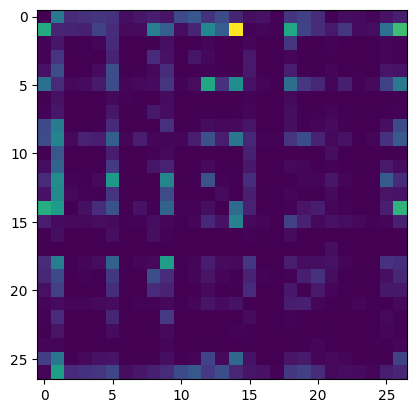

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)

In [ ]:
p=N[0].float()
p=p/p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [ ]:
g=torch.Generator().manual_seed(2147)


In [ ]:
i=torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()

itos[i]

'b'

In [ ]:
torch.multinomial(p,num_samples=100,replacement=True,generator=g)

tensor([19,  9, 19, 14, 26, 23, 13,  2,  8, 19,  7, 14,  1,  5, 12, 19,  5,  2,
        10,  7, 13,  8, 13, 20, 14,  1,  5, 13, 12,  1, 23, 19, 17, 11,  5,  1,
        19,  2, 12,  2,  1, 11,  1, 13, 13, 20, 14,  7,  4,  1,  1, 18,  1, 10,
        13,  2, 10, 11, 13,  7, 19, 13, 12, 11, 11, 19, 10, 13, 12,  8,  9,  5,
        12,  1, 19,  2,  8, 18, 19, 21,  5,  1, 19, 20, 25, 10, 18, 20, 26, 14,
        11, 20, 17, 14,  3, 13,  1,  5, 13,  4])

In [ ]:
P=(N+1).float()
P/=P.sum(1,keepdims=True)

In [ ]:
for i in range(10):
  out=[]
  ix=0
  while True:
    #p=N[ix].float()
    #p=p/p.sum()
    p=P[ix]
    ix=torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
    out.append(itos[ix])
    if ix==0:
      break
  print(' '.join(out))

a .
a r v i .
a .
m i n .
r i e a .
k y s e y d e .
i a r a h .
m a n .
n y a r a .
a h .


In [ ]:
log_likelihood=0.0
n=0
for w in words:
  chs=['.']+list(w)+['.']
  for ch1,ch2 in zip(chs,chs[1:]):
    i1=stoi[ch1]
    i2=stoi[ch2]
    prob=P[i1,i2]
    logprob=torch.log(prob)
    log_likelihood+=logprob
    n+=1
nll=-log_likelihood
print(nll)
print(nll/n)

tensor(559951.5625)
tensor(2.4544)


In [ ]:
xs,ys=[],[]
for w in words[:1]:
  chs=['.']+list(w)+['.']
  for ch1,ch2 in zip(chs,chs[1:]):
    i1=stoi[ch1]
    i2=stoi[ch2]
    xs.append(i1)
    ys.append(i2)
xs=torch.tensor(xs)
ys=torch.tensor(ys)


In [ ]:
import torch.nn.functional as F
xenc=F.one_hot(xs,num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
W=torch.randn((27,27),requires_grad=True)
xenc@W

tensor([[ 0.0682, -1.4182, -0.5674,  1.5383,  0.1584, -0.0841, -0.4108,  0.9548,
         -2.1267, -1.2267,  0.7588,  0.6839,  0.0880,  1.3251,  0.8811,  0.1204,
          0.0440,  1.1428,  0.4431,  1.3865,  1.3468, -0.1787, -0.8941,  1.6015,
         -1.3659,  0.4827,  1.2228],
        [ 0.5340,  0.5203,  0.4601,  0.7665, -1.0102,  1.7872,  0.5894, -0.5044,
         -0.9070,  0.4432, -2.0303, -0.6192, -1.1143, -1.5732, -0.6709, -0.1782,
          0.0586, -0.1401, -0.1883,  1.5822, -0.1136, -1.5058,  2.4139,  0.4755,
          1.6941, -0.7453, -1.3695],
        [-0.1710, -1.7355,  0.0827, -2.5503, -1.1204, -1.0550,  0.5128,  0.6728,
          0.6538, -2.3060, -0.8132, -0.1975,  0.3010, -0.8360, -0.4459,  0.3460,
          0.3979, -2.6436, -0.9122,  1.1214, -0.9246,  1.9991,  0.7339,  0.2514,
         -1.3236,  1.4962,  0.6857],
        [-0.1710, -1.7355,  0.0827, -2.5503, -1.1204, -1.0550,  0.5128,  0.6728,
          0.6538, -2.3060, -0.8132, -0.1975,  0.3010, -0.8360, -0.4459,  0.3460

In [ ]:
logits=xenc@W
counts=logits.exp()
prob=counts/counts.sum(1,keepdims=True)
prob

tensor([[0.0215, 0.0049, 0.0114, 0.0934, 0.0235, 0.0184, 0.0133, 0.0521, 0.0024,
         0.0059, 0.0428, 0.0397, 0.0219, 0.0754, 0.0484, 0.0226, 0.0210, 0.0629,
         0.0312, 0.0802, 0.0771, 0.0168, 0.0082, 0.0995, 0.0051, 0.0325, 0.0681],
        [0.0355, 0.0350, 0.0330, 0.0448, 0.0076, 0.1242, 0.0375, 0.0126, 0.0084,
         0.0324, 0.0027, 0.0112, 0.0068, 0.0043, 0.0106, 0.0174, 0.0221, 0.0181,
         0.0172, 0.1012, 0.0186, 0.0046, 0.2325, 0.0335, 0.1132, 0.0099, 0.0053],
        [0.0231, 0.0048, 0.0298, 0.0021, 0.0089, 0.0095, 0.0457, 0.0537, 0.0527,
         0.0027, 0.0121, 0.0225, 0.0370, 0.0119, 0.0175, 0.0387, 0.0408, 0.0019,
         0.0110, 0.0841, 0.0109, 0.2022, 0.0571, 0.0352, 0.0073, 0.1223, 0.0544],
        [0.0231, 0.0048, 0.0298, 0.0021, 0.0089, 0.0095, 0.0457, 0.0537, 0.0527,
         0.0027, 0.0121, 0.0225, 0.0370, 0.0119, 0.0175, 0.0387, 0.0408, 0.0019,
         0.0110, 0.0841, 0.0109, 0.2022, 0.0571, 0.0352, 0.0073, 0.1223, 0.0544],
        [0.0082, 0.0103,

In [ ]:
loss=-prob[torch.arange(5),ys].log().mean()

In [ ]:
print(loss.item())

4.800992012023926


In [ ]:
W.grad=None
loss.backward

<bound method Tensor.backward of tensor(4.8010, grad_fn=<NegBackward0>)>